In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [10]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [13]:
#Train & Evaluate All Models
results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    predictions = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    # Store Results
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

In [17]:
#Comparison Table
results_df = pd.DataFrame(results)
results_df


,Model,MAE,RMSE,R2 Score
0,Linear Regression,31.047180,59.169532,0.808802
1,Decision Tree,28.353320,55.548521,0.831487
2,Random Forest,20.481757,40.355191,0.911062
3,Gradient Boosting,23.361977,43.887239,0.894813


In [18]:
#Step 5: Sort by Best Model
results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Random Forest,20.481757,40.355191,0.911062
3,Gradient Boosting,23.361977,43.887239,0.894813
1,Decision Tree,28.353320,55.548521,0.831487
0,Linear Regression,31.047180,59.169532,0.808802


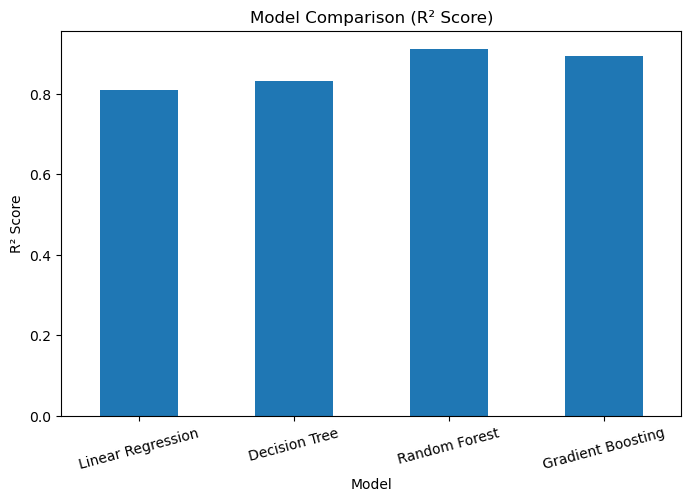

In [19]:
import matplotlib.pyplot as plt

results_df.plot(
    x="Model",
    y="R2 Score",
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.xticks(rotation=15)

plt.show()

## Model Comparison

### Observation

- Random Forest achieved the highest R² score among all evaluated models.
- Gradient Boosting produced comparable performance.
- Decision Tree outperformed the Linear Regression baseline.
- Linear Regression provided a strong baseline despite its simplicity.

### Interpretation

- Ensemble learning methods significantly improve AQI prediction accuracy.
- Random Forest is selected as the candidate model for further optimization and deployment.
- The comparison demonstrates the importance of evaluating multiple algorithms rather than relying on a single model.

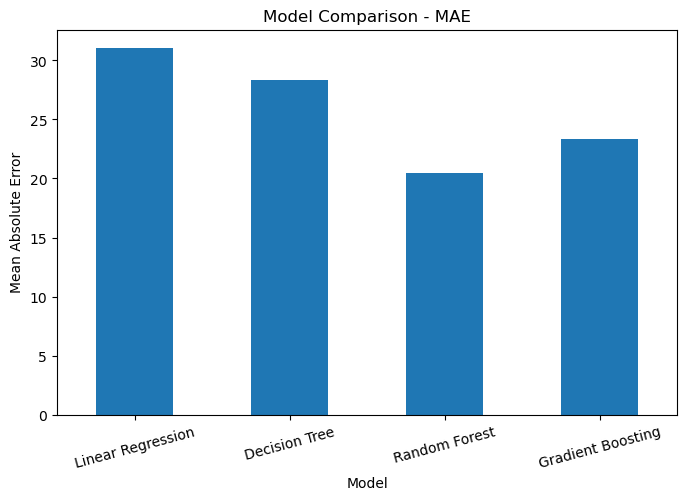

In [21]:
#MAE Comparision of different models
results_df.plot(
    x="Model",
    y="MAE",
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.title("Model Comparison - MAE")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=15)
plt.show()

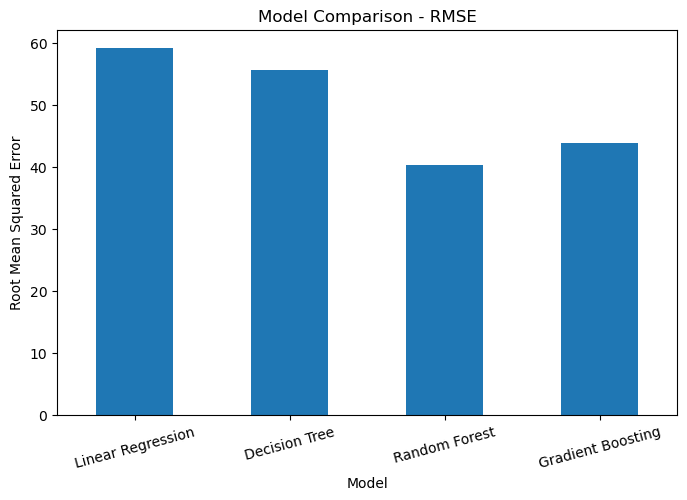

In [22]:
#RMSE Comparision for different models

results_df.plot(
    x="Model",
    y="RMSE",
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.title("Model Comparison - RMSE")
plt.ylabel("Root Mean Squared Error")
plt.xticks(rotation=15)
plt.show()

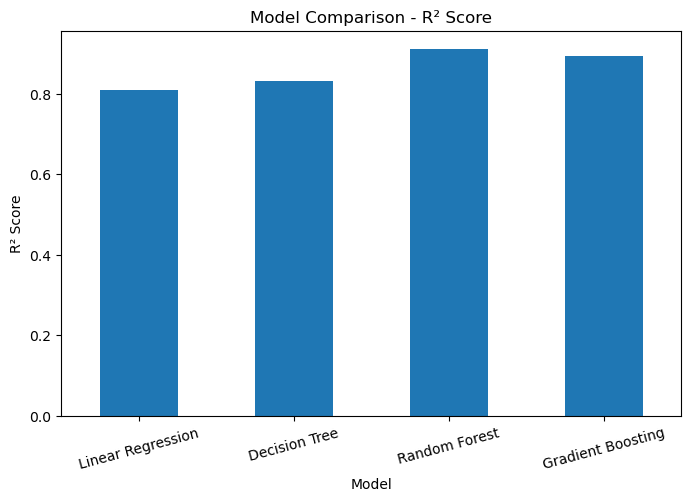

In [23]:
#R2 score Model Comparision
results_df.plot(
    x="Model",
    y="R2 Score",
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.title("Model Comparison - R² Score")
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.show()

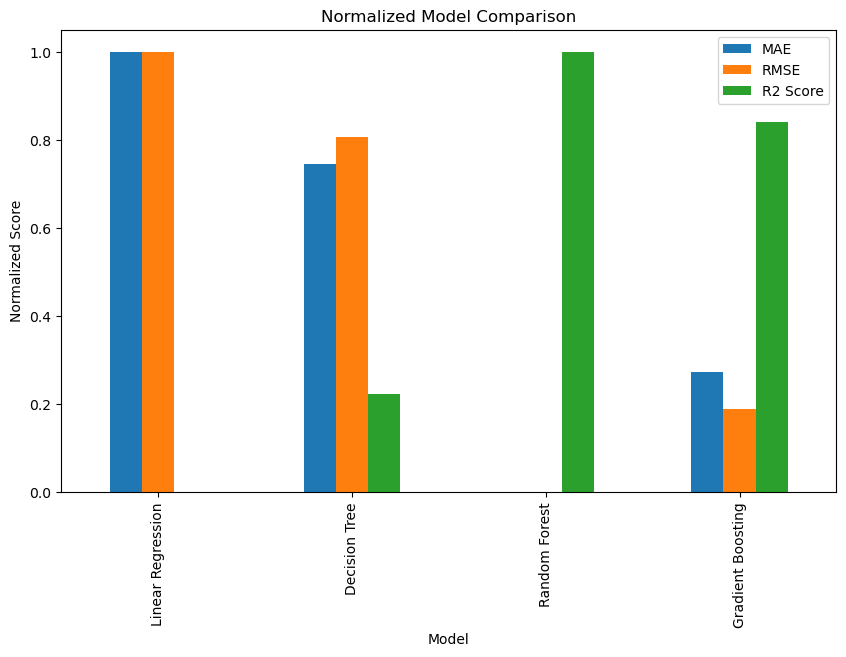

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

plot_df = results_df.copy()
plot_df[["MAE", "RMSE", "R2 Score"]] = scaler.fit_transform(
    plot_df[["MAE", "RMSE", "R2 Score"]]
)

plot_df.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Normalized Model Comparison")
plt.ylabel("Normalized Score")
plt.show()